In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df=pd.read_csv("flats_missing_val.csv")

In [20]:
df.head()

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,...,1,1,1,0,0,0,135.0,37,3.0,New Property
1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,...,1,1,0,0,0,1,150.0,31,3.0,New Property
2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,8.0,3.55,10.0,2720.0,1.0,1.0,...,1,1,1,1,1,1,156.0,49,3.0,New Property
3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,8.0,4.45,7.6,2067.2,1.0,2.0,...,1,0,0,0,0,1,125.0,18,3.0,New Property
4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,...,1,1,0,0,0,1,100.0,18,3.0,New Property


In [21]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

In [22]:
drop_cols = [
    'link',
    'society',
    'area',
    'price_per_sqft'
]

train_df=df.drop(columns=drop_cols)

In [23]:
train_df.head()

,bedrooms,baths,floors_in_building,price,area_sqft,servant_quarters,kitchens,store_rooms,drawing_room,dining_room,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,4.0,4.0,9.0,4.55,3264.0,1.0,1.0,1.0,1,1,...,1,1,1,0,0,0,135.0,37,3.0,New Property
1,4.0,5.0,10.0,4.50,3318.4,1.0,1.0,0.0,1,1,...,1,1,0,0,0,1,150.0,31,3.0,New Property
2,3.0,4.0,8.0,3.55,2720.0,1.0,1.0,1.0,1,1,...,1,1,1,1,1,1,156.0,49,3.0,New Property
3,4.0,4.0,8.0,4.45,2067.2,1.0,2.0,1.0,1,1,...,1,0,0,0,0,1,125.0,18,3.0,New Property
4,4.0,5.0,10.0,4.65,3318.4,1.0,1.0,1.0,1,1,...,1,1,0,0,0,1,100.0,18,3.0,New Property


In [24]:
train_df.columns

Index(['bedrooms', 'baths', 'floors_in_building', 'price', 'area_sqft',
       'servant_quarters', 'kitchens', 'store_rooms', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

<Axes: xlabel='luxury_score'>

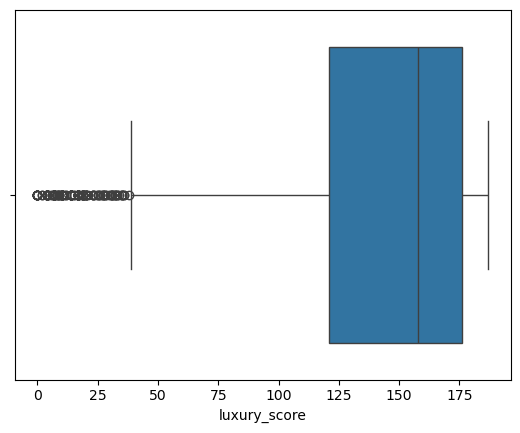

In [25]:
sns.boxplot(x=df['luxury_score'])

In [26]:
def categorize_luxury(score):
    if score < 120:
        return "Low"
    elif 120 <= score < 155:
        return "Medium"
    elif 155 <= score < 175:
        return "High"
    else:
        return "Very High"

| Range    | Category                     |
| -------- | ---------------------------- |
| Lowest   | Budget                       |
| Mid-low  | Semi-Luxury                  |
| Mid-high | Luxury                       |
| Highest  | **Ultra Luxury / Premium** ⭐ |


In [27]:
q1 = train_df['luxury_score'].quantile(0.25)
q2 = train_df['luxury_score'].quantile(0.50)
q3 = train_df['luxury_score'].quantile(0.75)

def categorize_luxury(score):
    if score < q1:
        return "Low"
    elif score < q2:
        return "Medium"
    elif score < q3:
        return "High"
    else:
        return "Very High"


In [28]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floor'>

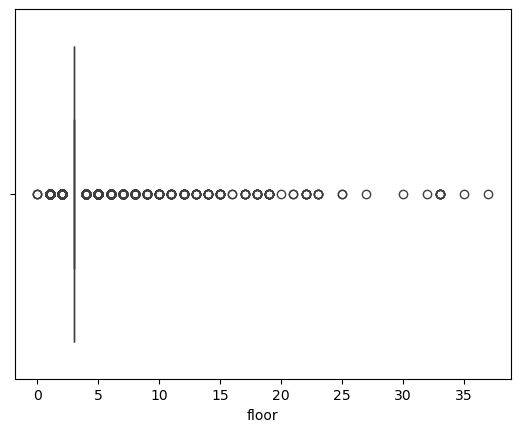

In [29]:
sns.boxplot(x=df['floor'])

In [30]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif floor >= 11:
        return "High Floor"
    else:
        return None

train_df['floor_category'] = train_df['floor'].apply(categorize_floor)

In [31]:
train_df['floor_category'].value_counts()

floor_category
Mid Floor     2390
Low Floor      526
High Floor     118
Name: count, dtype: int64

In [32]:
train_df.drop(columns=['floor', 'luxury_score'], inplace=True)

In [33]:
train_df.columns

Index(['bedrooms', 'baths', 'floors_in_building', 'price', 'area_sqft',
       'servant_quarters', 'kitchens', 'store_rooms', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'furnishing_score', 'agePossession', 'luxury_category',
       'floor_category'],
      dtype='object')

### Note 
- As we use ordinal encoding so results on `linear-models` are not reliable.

In [34]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = data_label_encoded.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_label_encoded[categorical_cols] = oe.fit_transform(data_label_encoded[categorical_cols])

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [35]:
X_label

,bedrooms,baths,floors_in_building,area_sqft,servant_quarters,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,...,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,furnishing_score,agePossession,luxury_category,floor_category
0,4.0,4.0,9.0,3264.0,1.0,1.0,1.0,1,1,1,...,1,1,1,0,0,0,37,1.0,2.0,2.0
1,4.0,5.0,10.0,3318.4,1.0,1.0,0.0,1,1,0,...,1,1,0,0,0,1,31,1.0,2.0,2.0
2,3.0,4.0,8.0,2720.0,1.0,1.0,1.0,1,1,1,...,1,1,1,1,1,1,49,1.0,2.0,2.0
3,4.0,4.0,8.0,2067.2,1.0,2.0,1.0,1,1,0,...,1,0,0,0,0,1,18,1.0,2.0,2.0
4,4.0,5.0,10.0,3318.4,1.0,1.0,1.0,1,1,0,...,1,1,0,0,0,1,18,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029,2.0,1.0,10.0,544.0,0.0,1.0,0.0,0,1,0,...,0,0,0,0,0,1,31,1.0,2.0,2.0
3030,2.0,2.0,8.0,680.0,0.0,1.0,0.0,0,0,0,...,0,0,0,0,0,0,0,4.0,1.0,2.0
3031,3.0,4.0,5.0,3155.2,0.0,1.0,0.0,1,1,1,...,1,1,1,1,1,1,49,3.0,3.0,2.0
3032,2.0,2.0,5.0,788.8,0.0,1.0,0.0,1,1,1,...,0,1,1,1,1,1,39,3.0,2.0,2.0


## 8 feature selection techniques

## Technique 1: Correlation Analysis

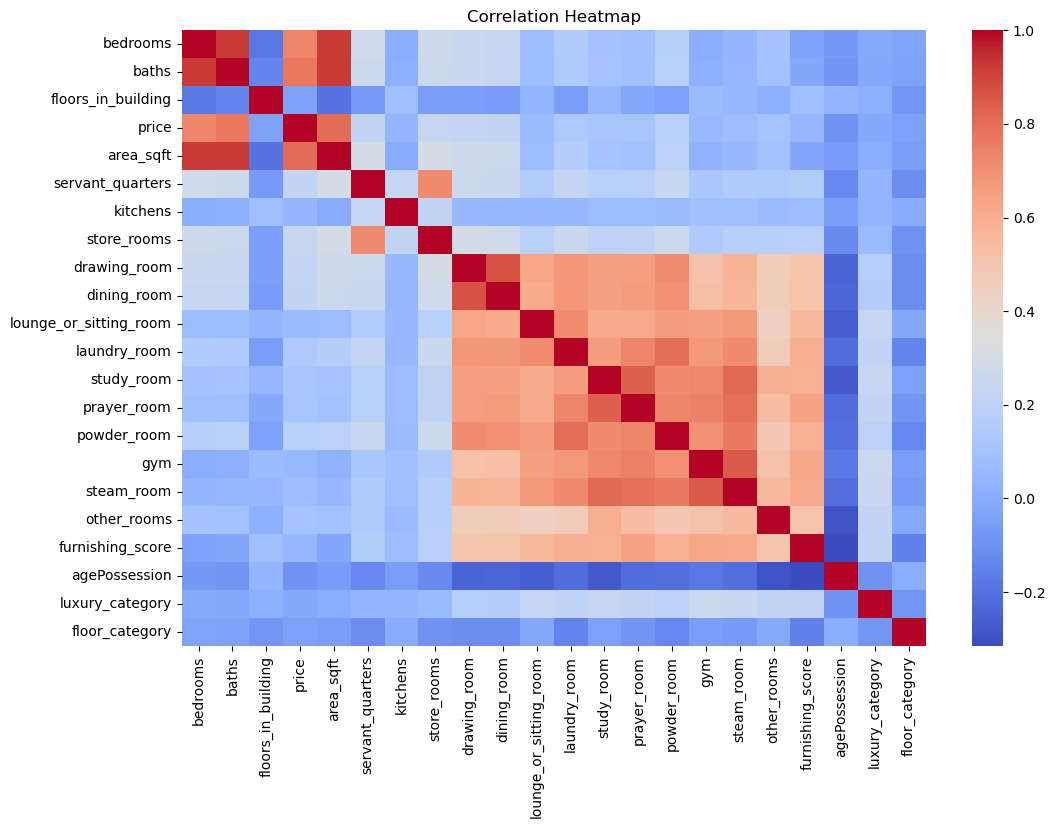

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(data_label_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [43]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price': 'corr_coeff'})
fi_df1.sort_values(by='corr_coeff', ascending=False)

,feature,corr_coeff
2,price,1.000000
3,area_sqft,0.802995
0,baths,0.768971
6,store_rooms,0.234526
7,drawing_room,0.224707
4,servant_quarters,0.217528
8,dining_room,0.216735
13,powder_room,0.180206
10,laundry_room,0.132350
11,study_room,0.114718


### 📌 Technique 2: Random Forest Feature Importance


In [44]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
3,area_sqft,0.795332
2,floors_in_building,0.040814
18,agePossession,0.029561
0,bedrooms,0.019464
17,furnishing_score,0.019123
1,baths,0.017634
19,luxury_category,0.015189
6,store_rooms,0.009858
20,floor_category,0.008682
4,servant_quarters,0.008479


### 📌 Technique 3: Gradient Boosting Feature Importance


In [45]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
3,area_sqft,0.893357
2,floors_in_building,0.031112
1,baths,0.022056
18,agePossession,0.018476
0,bedrooms,0.011693
17,furnishing_score,0.007528
6,store_rooms,0.003087
4,servant_quarters,0.003059
19,luxury_category,0.002231
20,floor_category,0.001830


### 📌 Technique 3: Gradient Boosting Feature Importance

In [46]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
3,area_sqft,0.893286
2,floors_in_building,0.031514
1,baths,0.022143
18,agePossession,0.018362
0,bedrooms,0.011408
17,furnishing_score,0.008010
6,store_rooms,0.003096
4,servant_quarters,0.003030
19,luxury_category,0.002225
20,floor_category,0.001819


### 📌 Technique 4: Permutation Importance

Permutation Importance measures how much a model’s performance decreases when a feature’s values are randomly shuffled.  
If shuffling a feature significantly reduces model performance, that feature is important.


In [47]:

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train-test split
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(
    X_label, y_label, test_size=0.2, random_state=42
)

# Train model
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Compute permutation importance
perm_importance = permutation_importance(
    rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42
)

# Store results
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
3,area_sqft,1.768055
0,bedrooms,0.068480
2,floors_in_building,0.054098
1,baths,0.031019
18,agePossession,0.030363
7,drawing_room,0.013849
19,luxury_category,0.006371
5,kitchens,0.003767
17,furnishing_score,0.003424
20,floor_category,0.002318


### 📌 Technique 5: LASSO (Feature Selection)

LASSO (L1 Regularization) helps in feature selection by shrinking less important feature coefficients to zero.


In [48]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train LASSO model
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
3,area_sqft,1.220570
1,baths,0.335999
2,floors_in_building,0.170305
17,furnishing_score,0.101548
5,kitchens,0.053881
14,gym,0.023082
13,powder_room,0.018372
12,prayer_room,0.008130
20,floor_category,0.007166
16,other_rooms,0.000000


### 📌 Technique 6: RFE (Recursive Feature Elimination)

RFE selects important features by recursively removing the least important ones based on a model.


In [49]:

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Initialize model
estimator = RandomForestRegressor()

# Apply RFE
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get selected features
selected_features = X_label.columns[selector_label.support_]

# Get importance scores
selected_coefficients = selector_label.estimator_.feature_importances_

# Store results
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
3,area_sqft,0.792042
2,floors_in_building,0.042193
18,agePossession,0.028530
0,bedrooms,0.019408
17,furnishing_score,0.018826
1,baths,0.018757
19,luxury_category,0.014895
4,servant_quarters,0.009511
20,floor_category,0.009492
6,store_rooms,0.009415


### 📌 Technique 7: Linear Regression Weights

Linear Regression assigns coefficients (weights) to each feature, indicating their impact on the target variable.

In [50]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
3,area_sqft,1.322776
1,baths,0.411618
2,floors_in_building,0.181787
17,furnishing_score,0.110306
13,powder_room,0.080803
5,kitchens,0.064307
12,prayer_room,0.063404
14,gym,0.060872
6,store_rooms,0.023600
20,floor_category,0.020843


### 📌 SHAP Feature Importance (TreeExplainer)


In [51]:
!pip install shap

In [52]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

# SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Mean absolute SHAP importance
shap_sum = np.abs(shap_values).mean(axis=0)

# Store results
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'shap_importance': shap_sum
}).sort_values(by='shap_importance', ascending=False)

fi_df8

c:\Users\zeeshan_ahmed\miniconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,shap_importance
3,area_sqft,1.343149
2,floors_in_building,0.106877
1,baths,0.104874
18,agePossession,0.087351
0,bedrooms,0.080516
19,luxury_category,0.042120
17,furnishing_score,0.033326
7,drawing_room,0.022212
20,floor_category,0.019096
6,store_rooms,0.017580


In [53]:
final_fi_df = fi_df1.merge(fi_df2, on='feature') \
                   .merge(fi_df3, on='feature') \
                   .merge(fi_df4, on='feature') \
                   .merge(fi_df5, on='feature') \
                   .merge(fi_df6, on='feature') \
                   .merge(fi_df7, on='feature') \
                   .merge(fi_df8, on='feature') \
                   .set_index('feature')
                   
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,shap_importance
feature,,,,,,,,
baths,0.768971,0.017634,0.022143,0.031019,0.335999,0.018757,0.411618,0.104874
floors_in_building,-0.034669,0.040814,0.031514,0.054098,0.170305,0.042193,0.181787,0.106877
area_sqft,0.802995,0.795332,0.893286,1.768055,1.220570,0.792042,1.322776,1.343149
servant_quarters,0.217528,0.008479,0.003030,0.000300,-0.039574,0.009511,-0.069912,0.015035
kitchens,0.043858,0.006380,0.000372,0.003767,0.053881,0.006411,0.064307,0.016510
store_rooms,0.234526,0.009858,0.003096,0.000335,0.000000,0.009415,0.023600,0.017580
drawing_room,0.224707,0.004367,0.000594,0.013849,-0.000000,0.005441,-0.024956,0.022212
dining_room,0.216735,0.002629,0.000114,0.000330,-0.000000,0.002800,-0.002404,0.007843
lounge_or_sitting_room,0.061729,0.003469,0.001137,-0.000145,-0.042926,0.003208,-0.056445,0.014098


In [54]:
## normalize 
final_fi_df = final_fi_df.div(final_fi_df.sum(axis=0), axis=1)

In [55]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','shap_importance']].mean(axis=1).sort_values(ascending=False)

feature
area_sqft                 0.832881
floors_in_building        0.040345
agePossession             0.028034
baths                     0.026304
furnishing_score          0.013262
luxury_category           0.011731
store_rooms               0.006461
floor_category            0.006348
drawing_room              0.005935
servant_quarters          0.005912
kitchens                  0.004834
lounge_or_sitting_room    0.003075
other_rooms               0.002863
steam_room                0.002005
dining_room               0.001998
gym                       0.001859
powder_room               0.001746
prayer_room               0.001680
laundry_room              0.001654
study_room                0.001073
dtype: float64

### model with all features

In [56]:
# with all the cols
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

scores.mean()

np.float64(0.4190417194752897)

In [57]:
# define features to drop
drop_cols = [
 'lounge_or_sitting_room','other_rooms','dining_room','steam_room',
 'gym','powder_room','prayer_room','laundry_room','study_room'
]

# create new dataset
X_reduced = X_label.drop(columns=drop_cols)

# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores_reduced = cross_val_score(rf, X_reduced, y_label, cv=5, scoring='r2')

scores_reduced.mean()

np.float64(0.4052888209114428)

In [61]:
# define features to drop
drop_cols = [
 'lounge_or_sitting_room','other_rooms','dining_room','steam_room',
 'gym','powder_room','prayer_room','laundry_room','study_room'
]

export_df = X_label.drop(columns=drop_cols)
export_df['price'] = y_label

export_df.to_csv('lahore_flats_post_feature_selection.csv', index=False)

In [62]:
export_df.head()

,bedrooms,baths,floors_in_building,area_sqft,servant_quarters,kitchens,store_rooms,drawing_room,furnishing_score,agePossession,luxury_category,floor_category,price
0,4.0,4.0,9.0,3264.0,1.0,1.0,1.0,1,37,1.0,2.0,2.0,4.55
1,4.0,5.0,10.0,3318.4,1.0,1.0,0.0,1,31,1.0,2.0,2.0,4.50
2,3.0,4.0,8.0,2720.0,1.0,1.0,1.0,1,49,1.0,2.0,2.0,3.55
3,4.0,4.0,8.0,2067.2,1.0,2.0,1.0,1,18,1.0,2.0,2.0,4.45
4,4.0,5.0,10.0,3318.4,1.0,1.0,1.0,1,18,1.0,1.0,2.0,4.65
